# Riccati ODE solver verification: manufactured solutions

Verify `solve_AB_euler` by comparing numerical output against closed-form
analytical solutions. We use a minimal 2-currency model where the matrix
Riccati ODE reduces to a scalar equation with known solution.

In [9]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from src import ModelParams, solve_AB_euler
from src.riccati import _V_of_A

np.set_printoptions(precision=10, suppress=True)

## Problem setup

We construct a 2-currency model with currencies `["REF", "X"]` where REF is
the reference currency ($\sigma_{\text{REF}} = 0$) and X has volatility $\sigma$.

$$\Sigma = \begin{pmatrix} 0 & 0 \\ 0 & \sigma^2 \end{pmatrix}$$

With this structure, the symmetric matrix $A$ stays in the form
$A = \bigl(\begin{smallmatrix} 0 & 0 \\ 0 & c \end{smallmatrix}\bigr)$
throughout the backward integration. The scalar $c = A_{11}$ satisfies:

**Linear ODE** (no trading, $M = 0$):
$$\dot{c} = -\sigma^2 c - \tfrac{\gamma}{2}\sigma^2, \qquad c(T) = \kappa$$
$$c(t) = \left(\kappa + \tfrac{\gamma}{2}\right) e^{\sigma^2(T-t)} - \tfrac{\gamma}{2}$$

**Scalar Riccati** (with trading, $M \neq 0$):
$$\dot{c} = 4m\,c^2 - \sigma^2 c - \tfrac{\gamma}{2}\sigma^2, \qquad c(T) = \kappa$$
where $m = M_{01} = M_{10}$. The two fixed points of the RHS are:
$$r_{1,2} = \frac{\sigma^2 \pm \sigma\sqrt{\sigma^2 + 8m\gamma}}{8m}$$
and the closed-form solution is:
$$c(t) = \frac{r_1 - r_2\,E(t)}{1 - E(t)}, \qquad E(t) = \frac{\kappa - r_1}{\kappa - r_2}\,e^{R(t-T)}, \quad R = \sigma\sqrt{\sigma^2 + 8m\gamma}$$

In [10]:
# --- Parameters ---
sigma = 0.2
gamma = 10.0
T = 2.0
m_val = 0.5
kappa_11 = 0.05


# --- Minimal 2-currency ModelParams ---
def make_test_mp(T_days, gamma, sigma, kappa_11=0.0):
    return ModelParams(
        currencies=["REF", "X"],
        ref_ccy="REF",
        sigma={"REF": 0.0, "X": sigma},
        corr={},
        k={},
        mu={"REF": 0.0, "X": 0.0},
        gamma=gamma,
        kappa=np.array([[0.0, 0.0], [0.0, kappa_11]]),
        T_days=T_days,
        pairs={},
    )


# --- Analytical solutions ---
def analytical_linear(t, T, sigma, gamma, kappa_11):
    """Exact A[1,1](t) for the linear ODE (M = 0)."""
    s2 = sigma**2
    return (kappa_11 + gamma / 2) * np.exp(s2 * (T - t)) - gamma / 2


def analytical_riccati(t, T, sigma, gamma, m, kappa_11):
    """Exact A[1,1](t) for the scalar Riccati ODE."""
    s2 = sigma**2
    disc = np.sqrt(s2 + 8 * m * gamma)
    r1 = (s2 + sigma * disc) / (8 * m)
    r2 = (s2 - sigma * disc) / (8 * m)
    R = sigma * disc

    E = ((kappa_11 - r1) / (kappa_11 - r2)) * np.exp(R * (t - T))
    return (r1 - r2 * E) / (1 - E)


# --- Trajectory recorder (mirrors solve_AB_euler logic) ---
def solve_trajectory(mp, M, Mtilde, P, Sigma, n_steps=2000):
    """Backward Euler recording full A[1,1] trajectory."""
    d = len(mp.currencies)
    U = np.ones(d)

    symM = M + M.T
    M_big = np.diag(symM @ U) - symM
    V = (Mtilde - Mtilde.T) @ U

    dt = mp.T_days / n_steps

    kappa = mp.kappa if mp.kappa is not None else np.zeros((d, d))
    A = kappa.copy()
    B = np.zeros(d)

    mu_vec = np.array([mp.mu.get(c, 0.0) for c in mp.currencies])
    Dmu = np.diag(mu_vec)

    t_grid = np.linspace(mp.T_days, 0, n_steps + 1)
    A11_traj = np.zeros(n_steps + 1)
    A11_traj[0] = A[1, 1]

    for step in range(n_steps):
        Vtilde = (_V_of_A(A, P) - _V_of_A(A, P).T) @ U
        A_dot = (
            2.0 * A @ M_big @ A
            - (Sigma * A)
            - 2.0 * Dmu @ A
            - 0.5 * mp.gamma * Sigma
        )
        B_dot = (
            mu_vec
            - Dmu @ B
            + 2.0 * A @ V
            + 2.0 * A @ Vtilde
            + 2.0 * A @ M_big @ B
        )

        A = A - dt * A_dot
        B = B - dt * B_dot
        A = 0.5 * (A + A.T)

        A11_traj[step + 1] = A[1, 1]

    return t_grid, A11_traj, A, B

## Test 1: Linear ODE ($M = 0$, no trading)

With $M = 0$ the quadratic term vanishes and each entry of $A$ evolves independently.
Only $A_{11}$ has nontrivial dynamics (exponential growth backward in time).

=== Test 1: Linear ODE (M = 0) ===
  A[1,1](0) numerical:   0.470597941176
  A[1,1](0) analytical:  0.470599691759
  Absolute error:        1.75e-06
  Relative error:        3.72e-06
  A[0,:] = [0. 0.]  (should be ~0)
  B0 = [0. 0.]  (should be [0, 0])


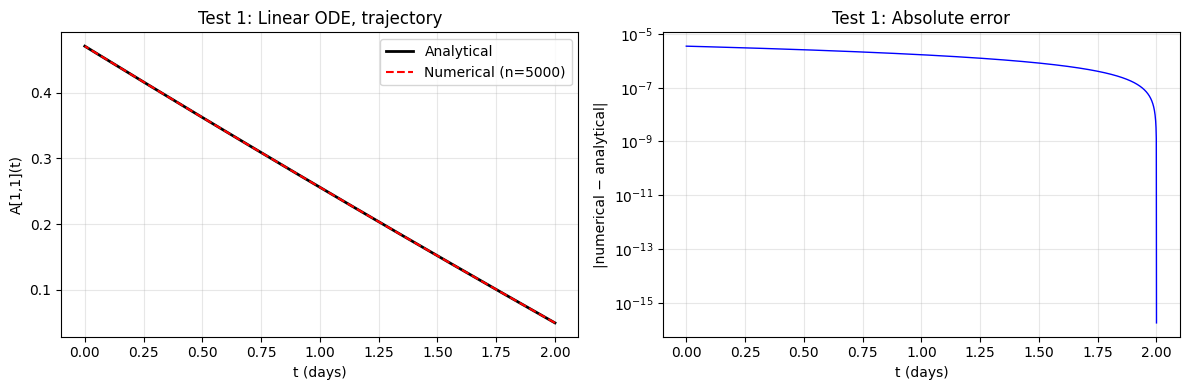

In [11]:
mp = make_test_mp(T, gamma, sigma, kappa_11)

d = 2
M_zero = np.zeros((d, d))
Sigma = np.array([[0.0, 0.0], [0.0, sigma**2]])

# Production solver
A0, B0 = solve_AB_euler(mp, M_zero, M_zero, M_zero, Sigma, n_steps=10000)
A11_exact = analytical_linear(0.0, T, sigma, gamma, kappa_11)

print("=== Test 1: Linear ODE (M = 0) ===")
print(f"  A[1,1](0) numerical:   {A0[1, 1]:.12f}")
print(f"  A[1,1](0) analytical:  {A11_exact:.12f}")
print(f"  Absolute error:        {abs(A0[1, 1] - A11_exact):.2e}")
print(f"  Relative error:        {abs(A0[1, 1] - A11_exact) / abs(A11_exact):.2e}")
print(f"  A[0,:] = {A0[0, :]}  (should be ~0)")
print(f"  B0 = {B0}  (should be [0, 0])")

# Full trajectory
t_grid, A11_traj, _, _ = solve_trajectory(
    mp, M_zero, M_zero, M_zero, Sigma, n_steps=5000
)
A11_exact_grid = analytical_linear(t_grid, T, sigma, gamma, kappa_11)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(t_grid, A11_exact_grid, "k-", lw=2, label="Analytical")
ax1.plot(t_grid, A11_traj, "r--", lw=1.5, label="Numerical (n=5000)")
ax1.set_xlabel("t (days)")
ax1.set_ylabel("A[1,1](t)")
ax1.set_title("Test 1: Linear ODE, trajectory")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.semilogy(t_grid[:-1], np.abs(A11_traj - A11_exact_grid)[:-1], "b-", lw=1)
ax2.set_xlabel("t (days)")
ax2.set_ylabel("|numerical \u2212 analytical|")
ax2.set_title("Test 1: Absolute error")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Test 2: Scalar Riccati ODE ($M \neq 0$)

With symmetric $M = \bigl(\begin{smallmatrix} 0 & m \\ m & 0 \end{smallmatrix}\bigr)$,
the quadratic term $2A\tilde{M}A$ contributes $4m\,c^2$ to the $(1,1)$ entry.
The resulting scalar Riccati ODE has a closed-form solution.

We also set $P \neq 0$ (and $\tilde{M} = M$, symmetric) to exercise the
$V(A, P)$ code path. The antisymmetric part $\tilde{V}$ should vanish
by the symmetry of the problem, so the solution is unaffected.

=== Test 2: Scalar Riccati ODE (M ≠ 0) ===
  Equilibria: r₁ = 0.32638584 (stable),  r₂ = -0.30638584
  A[1,1](0) numerical:   0.289613479199
  A[1,1](0) analytical:  0.289606891320
  Absolute error:        6.59e-06
  Relative error:        2.27e-05
  A[0,:] = [0. 0.]  (should be ~0)
  B0 = [0. 0.]  (should be [0, 0])


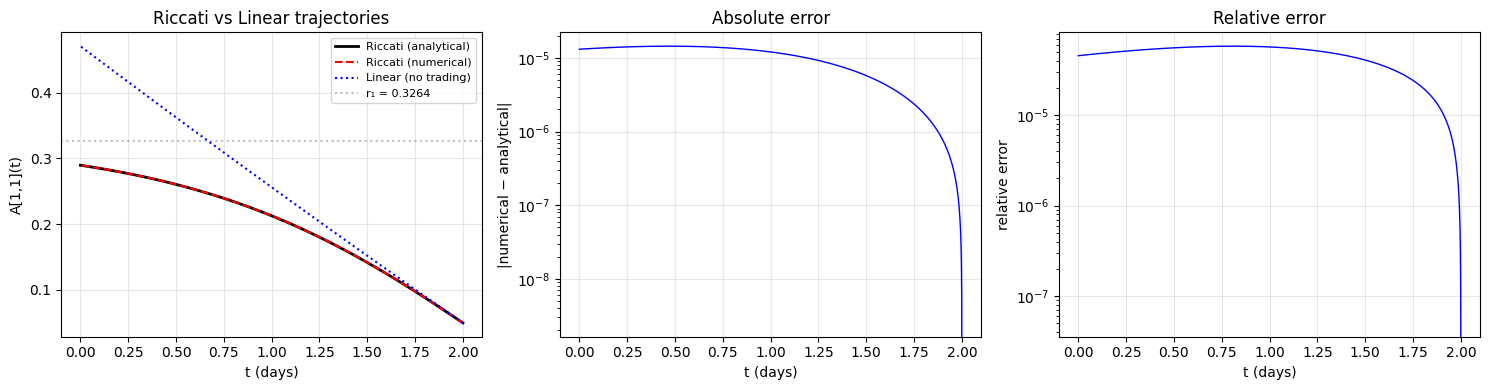

In [12]:
M = np.array([[0.0, m_val], [m_val, 0.0]])
P = np.array([[0.0, 0.5], [0.5, 0.0]])  # nonzero to exercise V(A,P)
Mtilde = M.copy()  # symmetric => V = 0

# Production solver
A0_ric, B0_ric = solve_AB_euler(mp, M, Mtilde, P, Sigma, n_steps=10000)
A11_exact_ric = analytical_riccati(0.0, T, sigma, gamma, m_val, kappa_11)

# Fixed points
s2 = sigma**2
disc = np.sqrt(s2 + 8 * m_val * gamma)
r1 = (s2 + sigma * disc) / (8 * m_val)
r2 = (s2 - sigma * disc) / (8 * m_val)

print("=== Test 2: Scalar Riccati ODE (M \u2260 0) ===")
print(f"  Equilibria: r\u2081 = {r1:.8f} (stable),  r\u2082 = {r2:.8f}")
print(f"  A[1,1](0) numerical:   {A0_ric[1, 1]:.12f}")
print(f"  A[1,1](0) analytical:  {A11_exact_ric:.12f}")
print(f"  Absolute error:        {abs(A0_ric[1, 1] - A11_exact_ric):.2e}")
print(f"  Relative error:        {abs(A0_ric[1, 1] - A11_exact_ric) / abs(A11_exact_ric):.2e}")
print(f"  A[0,:] = {A0_ric[0, :]}  (should be ~0)")
print(f"  B0 = {B0_ric}  (should be [0, 0])")

# Full trajectory
t_ric, A11_ric, _, _ = solve_trajectory(mp, M, Mtilde, P, Sigma, n_steps=5000)
A11_exact_ric_grid = analytical_riccati(t_ric, T, sigma, gamma, m_val, kappa_11)
A11_lin_grid = analytical_linear(t_ric, T, sigma, gamma, kappa_11)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(t_ric, A11_exact_ric_grid, "k-", lw=2, label="Riccati (analytical)")
axes[0].plot(t_ric, A11_ric, "r--", lw=1.5, label="Riccati (numerical)")
axes[0].plot(t_ric, A11_lin_grid, "b:", lw=1.5, label="Linear (no trading)")
axes[0].axhline(r1, color="gray", ls=":", alpha=0.5, label=f"r\u2081 = {r1:.4f}")
axes[0].set_xlabel("t (days)")
axes[0].set_ylabel("A[1,1](t)")
axes[0].set_title("Riccati vs Linear trajectories")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(
    t_ric[:-1], np.abs(A11_ric - A11_exact_ric_grid)[:-1], "b-", lw=1
)
axes[1].set_xlabel("t (days)")
axes[1].set_ylabel("|numerical \u2212 analytical|")
axes[1].set_title("Absolute error")
axes[1].grid(True, alpha=0.3)

safe_exact = np.maximum(np.abs(A11_exact_ric_grid[:-1]), 1e-15)
axes[2].semilogy(
    t_ric[:-1],
    np.abs(A11_ric - A11_exact_ric_grid)[:-1] / safe_exact,
    "b-",
    lw=1,
)
axes[2].set_xlabel("t (days)")
axes[2].set_ylabel("relative error")
axes[2].set_title("Relative error")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Convergence study

Verify that the backward Euler scheme converges at first order ($O(\Delta t)$)
by running `solve_AB_euler` with increasing `n_steps` and measuring the error
in $A_{11}(0)$.

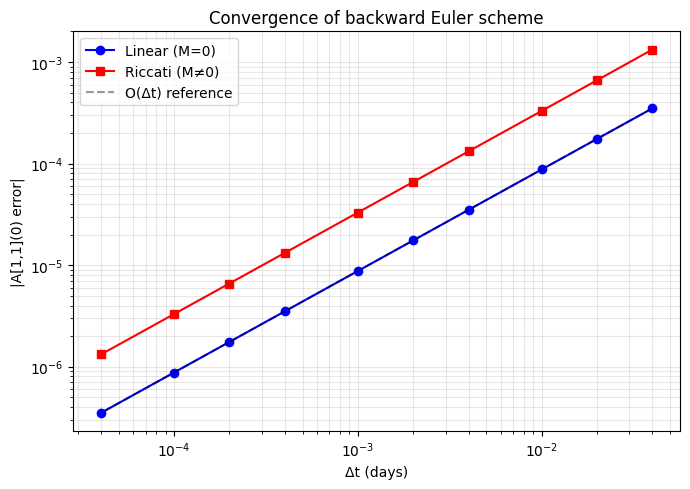


Convergence rates (successive ratios):
 n_steps          dt       err_lin       err_ric  rate_lin  rate_ric
      50    0.040000      3.50e-04      1.33e-03                    
     100    0.020000      1.75e-04      6.61e-04      1.00      1.01
     200    0.010000      8.75e-05      3.30e-04      1.00      1.00
     500    0.004000      3.50e-05      1.32e-04      1.00      1.00
    1000    0.002000      1.75e-05      6.59e-05      1.00      1.00
    2000    0.001000      8.75e-06      3.29e-05      1.00      1.00
    5000    0.000400      3.50e-06      1.32e-05      1.00      1.00
   10000    0.000200      1.75e-06      6.59e-06      1.00      1.00
   20000    0.000100      8.75e-07      3.29e-06      1.00      1.00
   50000    0.000040      3.50e-07      1.32e-06      1.00      1.00


In [13]:
n_steps_list = [50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]
errors_linear = []
errors_riccati = []

for ns in n_steps_list:
    A0_l, _ = solve_AB_euler(mp, M_zero, M_zero, M_zero, Sigma, n_steps=ns)
    errors_linear.append(abs(A0_l[1, 1] - A11_exact))

    A0_r, _ = solve_AB_euler(mp, M, Mtilde, P, Sigma, n_steps=ns)
    errors_riccati.append(abs(A0_r[1, 1] - A11_exact_ric))

dt_list = [T / ns for ns in n_steps_list]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(dt_list, errors_linear, "bo-", label="Linear (M=0)")
ax.loglog(dt_list, errors_riccati, "rs-", label="Riccati (M\u22600)")

# O(dt) reference line
dt_ref = np.array([dt_list[0], dt_list[-1]])
scale = errors_linear[2] / dt_list[2]
ax.loglog(dt_ref, scale * dt_ref, "k--", alpha=0.4, label="O(\u0394t) reference")

ax.set_xlabel("\u0394t (days)")
ax.set_ylabel("|A[1,1](0) error|")
ax.set_title("Convergence of backward Euler scheme")
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

# Print convergence rates
print("\nConvergence rates (successive ratios):")
print(
    f"{'n_steps':>8}  {'dt':>10}  {'err_lin':>12}  {'err_ric':>12}"
    f"  {'rate_lin':>8}  {'rate_ric':>8}"
)
for i, ns in enumerate(n_steps_list):
    if i == 0:
        rl = rr = ""
    else:
        ratio = np.log2(n_steps_list[i] / n_steps_list[i - 1])
        rl = f"{np.log2(errors_linear[i-1] / errors_linear[i]) / ratio:.2f}"
        rr = f"{np.log2(errors_riccati[i-1] / errors_riccati[i]) / ratio:.2f}"
    print(
        f"{ns:>8}  {dt_list[i]:>10.6f}"
        f"  {errors_linear[i]:>12.2e}  {errors_riccati[i]:>12.2e}"
        f"  {rl:>8}  {rr:>8}"
    )

## Summary

If the convergence rates are close to 1.0 and the errors decrease monotonically,
the backward Euler implementation in `solve_AB_euler` is correct for both the
linear ($\Sigma \odot A$ damping) and nonlinear ($2A\tilde{M}A$ Riccati) terms.

This does **not** test:
- The $D_\mu A$ drift term (we set $\mu = 0$)
- The $B$ equation (it stays at 0 by symmetry)
- The $\tilde{V}$ antisymmetric feedback (it vanishes by symmetry)

Those paths are inactive in the paper's base case too ($\mu = 0$,
symmetric parameters $\Rightarrow B \equiv 0$, $V = 0$, $\tilde{V} = 0$).